In [1]:
import pandas as pd
import gc
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pickle

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models, Input
from tensorflow.keras.layers import Dropout, GRU, Dense, TimeDistributed, Lambda, BatchNormalization, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.models import load_model

We have three versions of the augmented dataset.

For Stage 1, we trained each model version using its corresponding augmented data.

In [ ]:
data = np.load("../data/augmented_train_dataset_1.npz")
X_train = data["X_train"]
X_val = data["X_val"]
y_train = data["y_train"]
y_val = data["y_val"]
meta_train = data["meta_train"]
meta_val = data["meta_val"]

del data
gc.collect()

91

In [ ]:
data = np.load("../data/augmented_train_dataset_2.npz")
X_train = data["X_train"]
X_val = data["X_val"]
y_train = data["y_train"]
y_val = data["y_val"]
meta_train = data["meta_train"]
meta_val = data["meta_val"]

del data
gc.collect()

In [ ]:
data = np.load("../data/augmented_train_dataset_3.npz")
X_train = data["X_train"]
X_val = data["X_val"]
y_train = data["y_train"]
y_val = data["y_val"]
meta_train = data["meta_train"]
meta_val = data["meta_val"]

del data
gc.collect()

In [3]:
print("Train augmented dataset shapes:")
print("X_combined:", X_train.shape)
print("y_combined:", y_train.shape)
print("meta_combined:", meta_train.shape)

Train augmented dataset shapes:
X_combined: (2100, 24, 224, 224, 3)
y_combined: (2100,)
meta_combined: (2100, 5)


In [5]:
test_table = pd.read_pickle("../data/test_table.pkl")

X_test = np.stack(test_table["Frames"].values).astype("float32")
y_test = test_table["Label"].values
meta_test = test_table[["light_conditions", "weather_cloudy", "weather_rain", "scene_highway", "scene_rural"]].values

print("X_test shape:", X_test.shape)
print("meta_test shape:", meta_test.shape)
print("y_test shape:", y_test.shape)

del test_table
gc.collect()

X_test shape: (1344, 24, 224, 224, 3)
meta_test shape: (1344, 5)
y_test shape: (1344,)


1321

## Model

In [ ]:
# ---------- Base CNN ----------
cnn_base = MobileNetV2(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))
cnn_base.trainable = False  

# ---------- Video branch ----------
video_input = Input(shape=(24, 224, 224, 3), name="video_input")

x = TimeDistributed(Lambda(preprocess_input), name="td_preprocess")(video_input)
x = TimeDistributed(cnn_base, name="td_mobilenet")(x)

x = Bidirectional(GRU(64, return_sequences=True))(x)
x = Dropout(0.25)(x)
x = Bidirectional(GRU(64))(x)
x = Dropout(0.25)(x)

x = Dense(64, activation='relu', name="dense_video")(x)
x = BatchNormalization(name="bn_video")(x)
x = Dropout(0.3, name="dropout_3")(x)

# ---------- Metadata branch ----------
meta_input = Input(shape=(5,), name="meta_input")

m = Dense(16, activation='relu', name="dense_meta_1")(meta_input)
m = BatchNormalization(name="bn_meta_1")(m)
m = Dropout(0.3, name="dropout_meta")(m)
m = Dense(8, activation='relu', name="dense_meta_2")(m)
m = Lambda(lambda t: 0.3 * t, name="scale_meta")(m)

# ---------- Fusion ----------
combined = layers.concatenate([x, m], name="concat")
combined = Dense(16, activation='relu', name="dense_fusion")(combined)
combined = BatchNormalization(name="bn_fusion")(combined)
combined = Dropout(0.3, name="dropout_fusion")(combined)

output = Dense(1, activation='sigmoid', name="output")(combined)
model = models.Model(inputs=[video_input, meta_input], outputs=output)

optimizer_stage1 = Adam(learning_rate=1e-3)

model.compile(optimizer=optimizer_stage1, loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ video_input         │ (None, 24, 224,   │          0 │ -                 │
│ (InputLayer)        │ 224, 3)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_preprocess       │ (None, 24, 224,   │          0 │ video_input[0][0] │
│ (TimeDistributed)   │ 224, 3)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_mobilenet        │ (None, 24, 1280)  │  2,257,984 │ td_preprocess[0]… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 24, 128)   │    516,864 │ td_mobilenet[0][… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 24, 128)   │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ meta_input          │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 128)       │     74,496 │ dropout[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_meta_1        │ (None, 16)        │         96 │ meta_input[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_meta_1           │ (None, 16)        │         64 │ dense_meta_1[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_video (Dense) │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_meta        │ (None, 16)        │          0 │ bn_meta_1[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_video            │ (None, 64)        │        256 │ dense_video[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_meta_2        │ (None, 8)         │        136 │ dropout_meta[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ bn_video[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scale_meta (Lambda) │ (None, 8)         │          0 │ dense_meta_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 72)        │          0 │ dropout_3[0][0],  │
│ (Concatenate)       │                   │            │ scale_meta[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_fusion        │ (None, 16)        │      1,168 │ concat[0][0]      │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 2,859,401 (10.91 MB)

 Trainable params: 601,225 (2.29 MB)

 Non-trainable params: 2,258,176 (8.61 MB)

### Stage 1_1

In [ ]:
early_stop_stage1 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1)

reduce_lr_stage1 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1)

checkpoint_stage1 = ModelCheckpoint(
    "../models/model_stage1_best_1.keras",
    monitor='val_loss',
    save_best_only=True,
    verbose=1)

history_stage1 = model.fit(
    [X_train, meta_train],
    y_train,
    validation_data=([X_val, meta_val], y_val),
    epochs=15,
    batch_size=4,
    callbacks=[early_stop_stage1, reduce_lr_stage1, checkpoint_stage1],
    shuffle=True)


Epoch 1/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5294 - auc: 0.5238 - loss: 0.8582
Epoch 1: val_loss improved from None to 0.70705, saving model to model_stage1_best.keras
525/525 ━━━━━━━━━━━━━━━━━━━━ 1003s 2s/step - accuracy: 0.5310 - auc: 0.5297 - loss: 0.8086 - val_accuracy: 0.5000 - val_auc: 0.4263 - val_loss: 0.7071 - learning_rate: 0.0010
Epoch 2/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5378 - auc: 0.5606 - loss: 0.7255
Epoch 2: val_loss improved from 0.70705 to 0.70109, saving model to model_stage1_best.keras
525/525 ━━━━━━━━━━━━━━━━━━━━ 868s 2s/step - accuracy: 0.5281 - auc: 0.5405 - loss: 0.7308 - val_accuracy: 0.5000 - val_auc: 0.6044 - val_loss: 0.7011 - learning_rate: 0.0010
Epoch 3/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4896 - auc: 0.4750 - loss: 0.7462
Epoch 3: val_loss did not improve from 0.70109
525/525 ━━━━━━━━━━━━━━━━━━━━ 871s 2s/step - accuracy: 0.5043 - auc: 0.4910 - loss: 0.7304 - val_accuracy: 0.5000 - val_auc: 0.

In [ ]:
with open("../data/history_stage1_1.pkl", "wb") as f:
    pickle.dump(history_stage1.history, f)

### Stage 1_2

In [5]:
early_stop_stage1 = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1)

reduce_lr_stage1 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1)

checkpoint_stage1 = ModelCheckpoint(
    "../models/model_stage1_best_2.keras",
    monitor='val_loss',
    save_best_only=True,
    verbose=1)

history_stage1_2 = model.fit(
    [X_train, meta_train],
    y_train,
    validation_data=([X_val, meta_val], y_val),
    epochs=15,
    batch_size=4,
    callbacks=[early_stop_stage1, reduce_lr_stage1, checkpoint_stage1],
    shuffle=True)


Epoch 1/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4810 - auc: 0.4650 - loss: 0.9238
Epoch 1: val_loss improved from None to 0.89448, saving model to ../models/model_stage1_best_2.keras
525/525 ━━━━━━━━━━━━━━━━━━━━ 1049s 2s/step - accuracy: 0.5071 - auc: 0.5076 - loss: 0.8344 - val_accuracy: 0.5000 - val_auc: 0.6199 - val_loss: 0.8945 - learning_rate: 0.0010
Epoch 2/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5023 - auc: 0.5135 - loss: 0.7619
Epoch 2: val_loss improved from 0.89448 to 0.69514, saving model to ../models/model_stage1_best_2.keras
525/525 ━━━━━━━━━━━━━━━━━━━━ 910s 2s/step - accuracy: 0.4990 - auc: 0.5094 - loss: 0.7548 - val_accuracy: 0.4978 - val_auc: 0.5979 - val_loss: 0.6951 - learning_rate: 0.0010
Epoch 3/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5037 - auc: 0.5052 - loss: 0.7272
Epoch 3: val_loss improved from 0.69514 to 0.69387, saving model to ../models/model_stage1_best_2.keras
525/525 ━━━━━━━━━━━━━━━━━━━━ 880s 2s/step - a

In [ ]:
import pickle

with open("../data/history_stage1_2.pkl", "wb") as f:
    pickle.dump(history_stage1_2.history, f)

### Stage 1_3

In [ ]:
early_stop_stage1 = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1)

reduce_lr_stage1 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1)

checkpoint_stage1 = ModelCheckpoint(
    "../data/model_stage1_best_3.keras",
    monitor='val_loss',
    save_best_only=True,
    verbose=1)

history_stage1 = model.fit(
    [X_train, meta_train],
    y_train,
    validation_data=([X_val, meta_val], y_val),
    epochs=15,
    batch_size=4,
    callbacks=[early_stop_stage1, reduce_lr_stage1, checkpoint_stage1],
    shuffle=True)


Epoch 1/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5035 - auc: 0.5112 - loss: 0.8412
Epoch 1: val_loss improved from None to 0.74152, saving model to model_stage1_best.keras
525/525 ━━━━━━━━━━━━━━━━━━━━ 939s 2s/step - accuracy: 0.4990 - auc: 0.5070 - loss: 0.8026 - val_accuracy: 0.5000 - val_auc: 0.5934 - val_loss: 0.7415 - learning_rate: 0.0010
Epoch 2/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5310 - auc: 0.5245 - loss: 0.7366
Epoch 2: val_loss improved from 0.74152 to 0.68795, saving model to model_stage1_best.keras
525/525 ━━━━━━━━━━━━━━━━━━━━ 799s 2s/step - accuracy: 0.5176 - auc: 0.5122 - loss: 0.7322 - val_accuracy: 0.5200 - val_auc: 0.6170 - val_loss: 0.6880 - learning_rate: 0.0010
Epoch 3/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5322 - auc: 0.5303 - loss: 0.7080
Epoch 3: val_loss did not improve from 0.68795
525/525 ━━━━━━━━━━━━━━━━━━━━ 790s 2s/step - accuracy: 0.5238 - auc: 0.5210 - loss: 0.7082 - val_accuracy: 0.4800 - val_auc: 0.4

### Stage 1 model selection

We trained three Stage-1 variants with different augmentation strengths (Stage 1_1: light, Stage 1_2: medium, Stage 1_3: heavy).
  
Based on validation performance, **Stage 1_3** achieved the best results, with a minimum validation loss of **0.604** and validation AUC of **≈0.75**, 
compared to **0.609 / 0.745** (Stage 1_2) and **0.612 / 0.745** (Stage 1_1).  

Therefore, **Stage 1_3 is selected as the best Stage-1 backbone.**


### Stage 2_10_1

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

model_stage2 = load_model("../models/model_stage1_best_1.keras",
    custom_objects={"preprocess_input": preprocess_input}, safe_mode=False)

cnn_base = model_stage2.get_layer("td_mobilenet").layer
cnn_base.trainable = False

n_unfreeze = 10
trainable_count = 0

for layer in reversed(cnn_base.layers):
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
        continue

    layer.trainable = True
    trainable_count += 1
    if trainable_count >= n_unfreeze:
        break

optimizer_stage2 = Adam(learning_rate=5e-5)

model_stage2.compile(
    optimizer=optimizer_stage2,
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])


In [6]:
early_stop = EarlyStopping(
    monitor='val_auc',
    patience=4,
    restore_best_weights=True,
    verbose=1)

reduce_lr = ReduceLROnPlateau(
    monitor='val_auc',
    factor=0.5,
    patience=2,
    verbose=1)

checkpoint = ModelCheckpoint(
    "../models/best_model_stage2_10_1.keras",
    monitor='val_auc',
    save_best_only=True,
    verbose=1)

history = model_stage2.fit(
    [X_train, meta_train],
    y_train,
    validation_data=([X_val, meta_val], y_val),
    epochs=40,
    batch_size=4,
    callbacks=[early_stop, reduce_lr, checkpoint],
    shuffle=True)


Epoch 1/40
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6367 - auc: 0.6737 - loss: 0.6490
Epoch 1: val_auc improved from None to 0.75635, saving model to ../models/best_model_stage2_10_1.keras
525/525 ━━━━━━━━━━━━━━━━━━━━ 1141s 2s/step - accuracy: 0.6305 - auc: 0.6731 - loss: 0.6497 - val_accuracy: 0.5267 - val_auc: 0.7563 - val_loss: 0.7446 - learning_rate: 5.0000e-05
Epoch 2/40
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6441 - auc: 0.6928 - loss: 0.6361
Epoch 2: val_auc improved from 0.75635 to 0.76217, saving model to ../models/best_model_stage2_10_1.keras
525/525 ━━━━━━━━━━━━━━━━━━━━ 976s 2s/step - accuracy: 0.6410 - auc: 0.6898 - loss: 0.6390 - val_accuracy: 0.5000 - val_auc: 0.7622 - val_loss: 0.8046 - learning_rate: 5.0000e-05
Epoch 3/40
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6701 - auc: 0.7132 - loss: 0.6233
Epoch 3: val_auc improved from 0.76217 to 0.77288, saving model to ../models/best_model_stage2_10_1.keras
525/525 ━━━━━━━━━━━━━━━━━━━━ 89

In [ ]:
import pickle
with open("../data/history_stage2_10_1.pkl", "wb") as f:
    pickle.dump(history.history, f)

In [6]:
best_model_2_10_1 = load_model("../models/best_model_stage2_10_1.keras",
    custom_objects={"preprocess_input": preprocess_input}, safe_mode=False)

In [12]:
results2 = best_model_2_10_1.evaluate([X_test, meta_test], y_test, batch_size=4)
print(f"Test Accuracy: {results2[1]*100:.2f}%")

336/336 ━━━━━━━━━━━━━━━━━━━━ 562s 2s/step - accuracy: 0.7217 - auc: 0.7820 - loss: 0.5715
Test Accuracy: 72.17%


In [7]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score

y_pred_prob = best_model_2_10_1.predict([X_test, meta_test])
y_pred = (y_pred_prob > 0.4).astype(int)

test_auc = roc_auc_score(y_test, y_pred_prob)


print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Test AUC:", test_auc)


42/42 ━━━━━━━━━━━━━━━━━━━━ 736s 15s/step

Classification Report:
              precision    recall  f1-score   support

           0      0.739     0.717     0.728       672
           1      0.725     0.747     0.736       672

    accuracy                          0.732      1344
   macro avg      0.732     0.732     0.732      1344
weighted avg      0.732     0.732     0.732      1344


Confusion Matrix:
[[482 190]
 [170 502]]
Test AUC: 0.782288566468254


In [12]:
def load_hist(name):
    with open(name, "rb") as f:
        return pickle.load(f)

h1 = load_hist("../data/history_stage1_1.pkl")
h2 = load_hist("../data/history_stage2_10_1.pkl")

def concat_metrics(*histories):
    keys = histories[0].keys()
    combined = {k: [] for k in keys}
    for h in histories:
        for k in keys:
            combined[k].extend(h[k])
    return combined

combined_hist = concat_metrics(h1, h2)

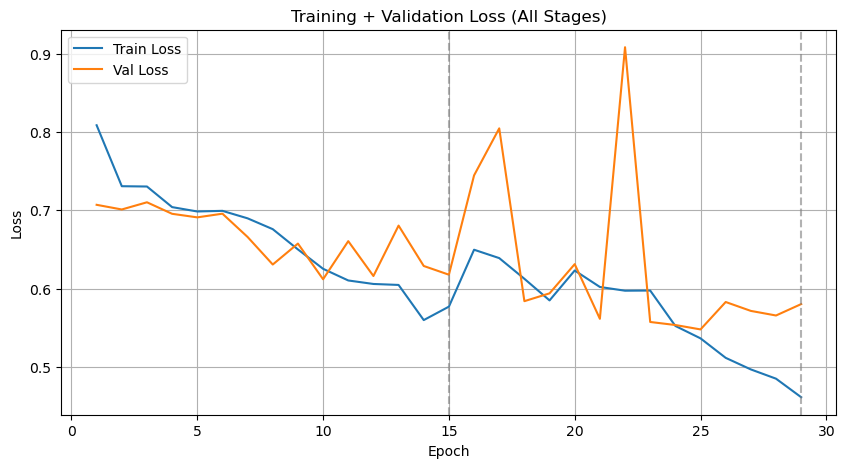

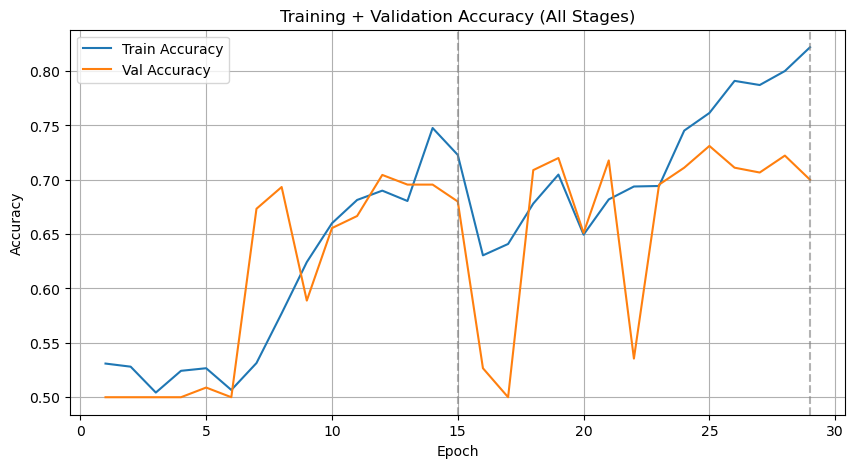

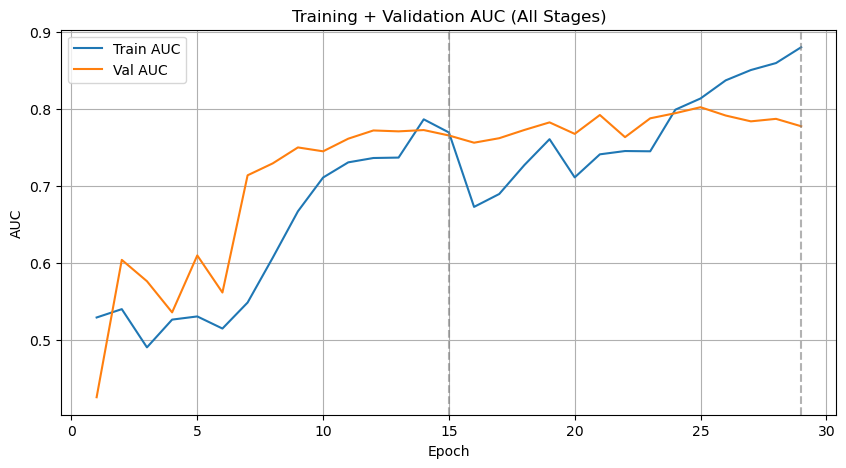

In [13]:
import matplotlib.pyplot as plt

epochs = range(1, len(combined_hist["loss"]) + 1)

plt.figure(figsize=(10,5))
plt.plot(epochs, combined_hist["loss"], label="Train Loss")
plt.plot(epochs, combined_hist["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training + Validation Loss (All Stages)")
plt.legend()
plt.grid(True)
stage1_end = len(h1["loss"])
stage2_end = stage1_end + len(h2["loss"])

for x in [stage1_end, stage2_end]:
    plt.axvline(x, linestyle='--', color='gray', alpha=0.6)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(epochs, combined_hist["accuracy"], label="Train Accuracy")
plt.plot(epochs, combined_hist["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training + Validation Accuracy (All Stages)")
plt.legend()
plt.grid(True)
stage1_end = len(h1["loss"])
stage2_end = stage1_end + len(h2["loss"])

for x in [stage1_end, stage2_end]:
    plt.axvline(x, linestyle='--', color='gray', alpha=0.6)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(epochs, combined_hist["auc"], label="Train AUC")
plt.plot(epochs, combined_hist["val_auc"], label="Val AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Training + Validation AUC (All Stages)")
plt.legend()
plt.grid(True)
import numpy as np

stage1_end = len(h1["loss"])
stage2_end = stage1_end + len(h2["loss"])

for x in [stage1_end, stage2_end]:
    plt.axvline(x, linestyle='--', color='gray', alpha=0.6)

plt.show()


### Stage 2_10_2

In [3]:
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

model_stage2 = load_model(
    "../models/model_stage1_best_2.keras",
    custom_objects={"preprocess_input": preprocess_input}, safe_mode=False)

cnn_base = model_stage2.get_layer("td_mobilenet").layer

cnn_base.trainable = False

n_unfreeze = 10
trainable_count = 0

for layer in reversed(cnn_base.layers):
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
        continue

    layer.trainable = True
    trainable_count += 1
    if trainable_count >= n_unfreeze:
        break

optimizer_stage2 = Adam(learning_rate=5e-5)

model_stage2.compile(
    optimizer=optimizer_stage2,
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])


In [4]:
early_stop_stage2 = EarlyStopping(
    monitor='val_auc',
    patience=4,
    restore_best_weights=True,
    verbose=1)

reduce_lr_stage2 = ReduceLROnPlateau(
    monitor='val_auc',
    factor=0.25,
    patience=2,
    verbose=1)

checkpoint_stage2 = ModelCheckpoint(
    "../models/best_model_stage2_10_2.keras",
    monitor='val_auc',
    save_best_only=True,
    verbose=1)


history_stage2 = model_stage2.fit(
    [X_train, meta_train],
    y_train,
    validation_data=([X_val, meta_val], y_val),
    epochs=40,
    batch_size=4,    
    callbacks=[early_stop_stage2, reduce_lr_stage2, checkpoint_stage2],
    shuffle=True)

Epoch 1/40
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5878 - auc: 0.6201 - loss: 0.6732
Epoch 1: val_auc improved from None to 0.75415, saving model to ../models/best_model_stage2_10_2.keras
525/525 ━━━━━━━━━━━━━━━━━━━━ 1095s 2s/step - accuracy: 0.6052 - auc: 0.6430 - loss: 0.6638 - val_accuracy: 0.6800 - val_auc: 0.7542 - val_loss: 0.6181 - learning_rate: 5.0000e-05
Epoch 2/40
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6441 - auc: 0.6819 - loss: 0.6422
Epoch 2: val_auc did not improve from 0.75415
525/525 ━━━━━━━━━━━━━━━━━━━━ 947s 2s/step - accuracy: 0.6481 - auc: 0.6879 - loss: 0.6382 - val_accuracy: 0.6578 - val_auc: 0.7509 - val_loss: 0.6170 - learning_rate: 5.0000e-05
Epoch 3/40
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6654 - auc: 0.7125 - loss: 0.6229
Epoch 3: val_auc improved from 0.75415 to 0.76513, saving model to ../models/best_model_stage2_10_2.keras
525/525 ━━━━━━━━━━━━━━━━━━━━ 957s 2s/step - accuracy: 0.6752 - auc: 0.7226 - loss: 0.6171 -

In [6]:
import pickle
with open("../data/history_stage2_10_2.pkl", "wb") as f:
    pickle.dump(history_stage2.history, f)

In [7]:
best_model_2_10_2 = load_model("../models/best_model_stage2_10_2.keras",
    custom_objects={"preprocess_input": preprocess_input}, safe_mode=False)

In [11]:
results2 = best_model_2_10_2.evaluate([X_test, meta_test], y_test, batch_size=4)
print(f"Test Accuracy: {results2[1]*100:.2f}%")

336/336 ━━━━━━━━━━━━━━━━━━━━ 495s 1s/step - accuracy: 0.6793 - auc: 0.7546 - loss: 0.6154
Test Accuracy: 67.93%


In [12]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_prob = best_model_2_10_2.predict([X_test, meta_test])
y_pred = (y_pred_prob > 0.4).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

42/42 ━━━━━━━━━━━━━━━━━━━━ 573s 13s/step

Classification Report:
              precision    recall  f1-score   support

           0      0.677     0.753     0.713       672
           1      0.722     0.641     0.679       672

    accuracy                          0.697      1344
   macro avg      0.700     0.697     0.696      1344
weighted avg      0.700     0.697     0.696      1344


Confusion Matrix:
[[506 166]
 [241 431]]


In [ ]:
def load_hist(name):
    with open(name, "rb") as f:
        return pickle.load(f)

h1 = load_hist("history_stage1.pkl")
h2 = load_hist("history_stage2.pkl")

def concat_metrics(*histories):
    keys = histories[0].keys()
    combined = {k: [] for k in keys}
    for h in histories:
        for k in keys:
            combined[k].extend(h[k])
    return combined

combined_hist = concat_metrics(h1, h2)



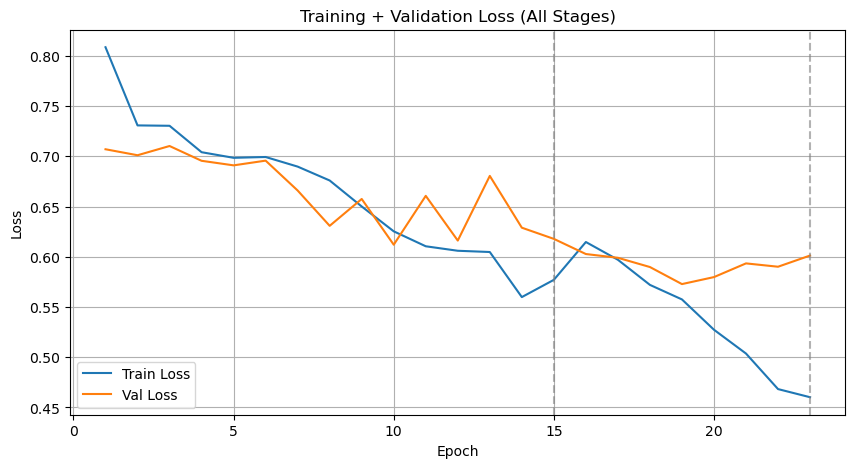

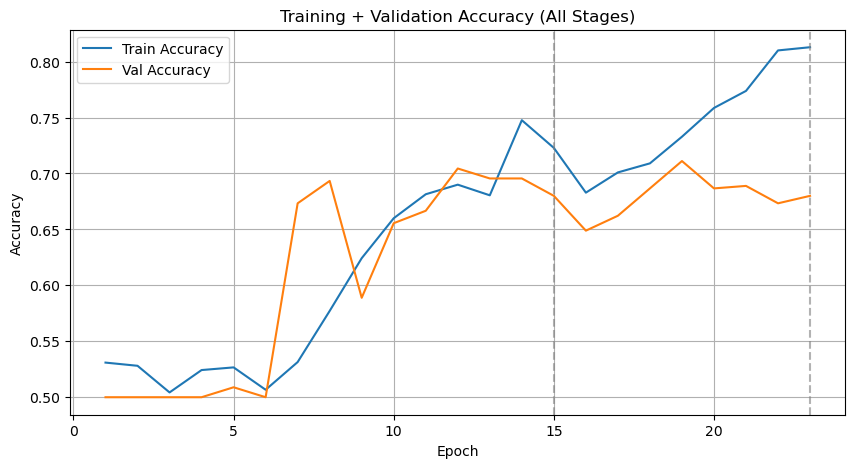

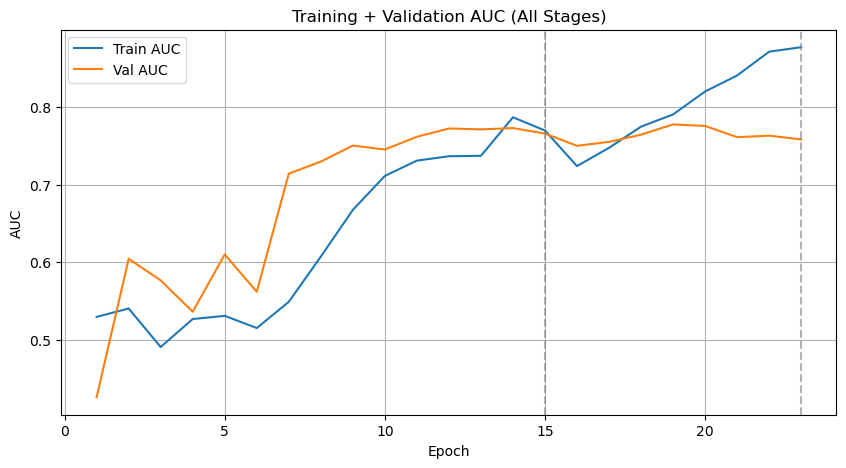

In [12]:
import matplotlib.pyplot as plt

epochs = range(1, len(combined_hist["loss"]) + 1)

plt.figure(figsize=(10,5))
plt.plot(epochs, combined_hist["loss"], label="Train Loss")
plt.plot(epochs, combined_hist["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training + Validation Loss (All Stages)")
plt.legend()
plt.grid(True)
stage1_end = len(h1["loss"])
stage2_end = stage1_end + len(h2["loss"])

for x in [stage1_end, stage2_end]:
    plt.axvline(x, linestyle='--', color='gray', alpha=0.6)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(epochs, combined_hist["accuracy"], label="Train Accuracy")
plt.plot(epochs, combined_hist["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training + Validation Accuracy (All Stages)")
plt.legend()
plt.grid(True)
stage1_end = len(h1["loss"])
stage2_end = stage1_end + len(h2["loss"])

for x in [stage1_end, stage2_end]:
    plt.axvline(x, linestyle='--', color='gray', alpha=0.6)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(epochs, combined_hist["auc"], label="Train AUC")
plt.plot(epochs, combined_hist["val_auc"], label="Val AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Training + Validation AUC (All Stages)")
plt.legend()
plt.grid(True)
import numpy as np

stage1_end = len(h1["loss"])
stage2_end = stage1_end + len(h2["loss"])

for x in [stage1_end, stage2_end]:
    plt.axvline(x, linestyle='--', color='gray', alpha=0.6)

plt.show()


Stage 2_10_3

In [3]:
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

model_stage2 = load_model(
    "../models/model_stage1_best_3.keras",
    custom_objects={"preprocess_input": preprocess_input}, safe_mode=False)

cnn_base = model_stage2.get_layer("td_mobilenet").layer

cnn_base.trainable = False

n_unfreeze = 10
trainable_count = 0

for layer in reversed(cnn_base.layers):
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
        continue

    layer.trainable = True
    trainable_count += 1
    if trainable_count >= n_unfreeze:
        break

optimizer_stage2 = Adam(learning_rate=4e-5)

model_stage2.compile(
    optimizer=optimizer_stage2,
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])


In [4]:
early_stop = EarlyStopping(
    monitor='val_auc',
    patience=5,
    restore_best_weights=True,
    verbose=1)

reduce_lr = ReduceLROnPlateau(
    monitor='val_auc',
    factor=0.5,
    patience=2,
    verbose=1)

checkpoint = ModelCheckpoint(
    "../models/best_model_stage2_10_3.keras",
    monitor='val_auc',
    save_best_only=True,
    verbose=1)

history = model_stage2.fit(
    [X_train, meta_train],
    y_train,
    validation_data=([X_val, meta_val], y_val),
    epochs=40,
    batch_size=4,
    callbacks=[early_stop, reduce_lr, checkpoint],
    shuffle=True)


Epoch 1/40
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5961 - auc: 0.6182 - loss: 0.6821
Epoch 1: val_auc improved from None to 0.74697, saving model to ../models/best_model_stage2_10_3.keras
525/525 ━━━━━━━━━━━━━━━━━━━━ 1046s 2s/step - accuracy: 0.6110 - auc: 0.6486 - loss: 0.6649 - val_accuracy: 0.5089 - val_auc: 0.7470 - val_loss: 1.1211 - learning_rate: 4.0000e-05
Epoch 2/40
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6124 - auc: 0.6661 - loss: 0.6467
Epoch 2: val_auc did not improve from 0.74697
525/525 ━━━━━━━━━━━━━━━━━━━━ 901s 2s/step - accuracy: 0.5810 - auc: 0.6236 - loss: 0.6722 - val_accuracy: 0.6489 - val_auc: 0.7297 - val_loss: 0.6443 - learning_rate: 4.0000e-05
Epoch 3/40
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6392 - auc: 0.6889 - loss: 0.6399
Epoch 3: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.

Epoch 3: val_auc did not improve from 0.74697
525/525 ━━━━━━━━━━━━━━━━━━━━ 880s 2s/step - accuracy: 0.6490 - auc: 0.699

In [5]:
with open("../data/history_stage2_10_3.pkl", "wb") as f:
    pickle.dump(history.history, f)

In [7]:
best_model_2_10_3 = load_model("../models/best_model_stage2_10_3.keras",
    custom_objects={"preprocess_input": preprocess_input}, safe_mode=False)

In [8]:
results = best_model_2_10_3.evaluate([X_test, meta_test], y_test, batch_size=4)
print(f"Test Accuracy: {results[1]*100:.2f}%")

336/336 ━━━━━━━━━━━━━━━━━━━━ 521s 1s/step - accuracy: 0.6786 - auc: 0.7512 - loss: 0.6238
Test Accuracy: 67.86%


In [10]:

def load_hist(name):
    with open(name, "rb") as f:
        return pickle.load(f)

h_3 = load_hist("../data/history_model_3.pkl")


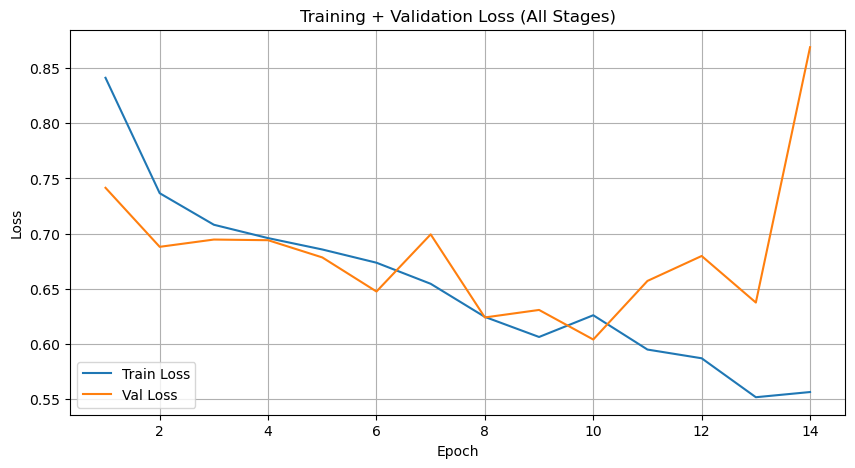

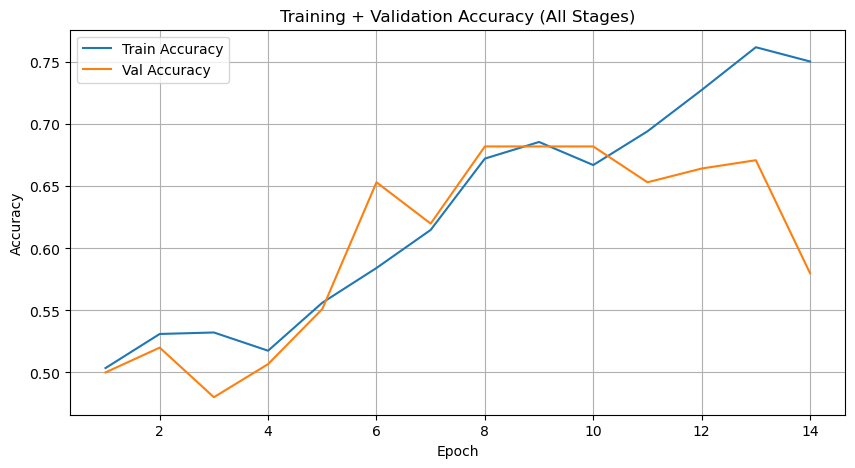

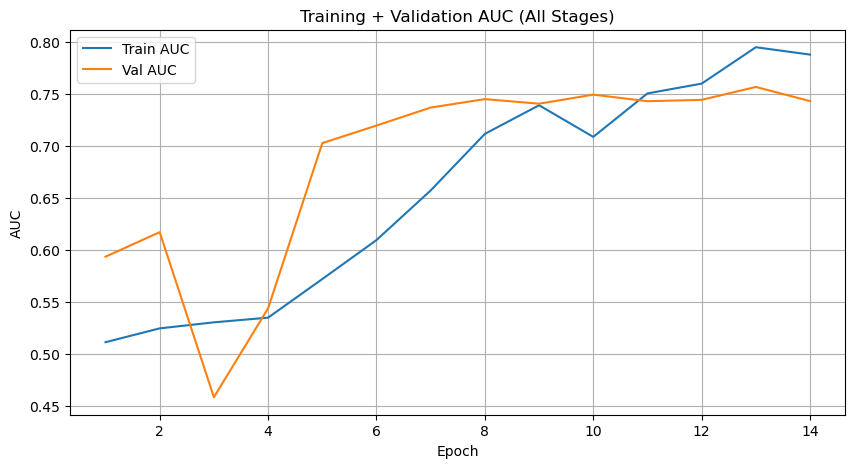

In [11]:
import matplotlib.pyplot as plt

epochs = range(1, len(h_3["loss"]) + 1)

plt.figure(figsize=(10,5))
plt.plot(epochs, h_3["loss"], label="Train Loss")
plt.plot(epochs, h_3["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training + Validation Loss (All Stages)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(epochs, h_3["accuracy"], label="Train Accuracy")
plt.plot(epochs, h_3["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training + Validation Accuracy (All Stages)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(epochs, h_3["auc"], label="Train AUC")
plt.plot(epochs, h_3["val_auc"], label="Val AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Training + Validation AUC (All Stages)")
plt.legend()
plt.grid(True)

plt.show()


Although Stage 1_3 achieved the lowest validation loss during backbone training, it did not produce the best results when entering Stage 2 fine-tuning. Heavy augmentation helped the model learn robust general features in Stage 1, but it introduced too much distortion during fine-tuning.

In Stage 2, the model initialized from Stage 1_1 (lighter augmentation) yielded the highest validation AUC (~0.80), showing that fine-tuning benefits from cleaner, less aggressively augmented inputs.

### Stage 3_1

In [3]:
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.optimizers import Adam


model_stage3 = load_model(
    "../models/best_model_stage2_10_1.keras",
    custom_objects={"preprocess_input": preprocess_input}, safe_mode=False)

cnn = model_stage3.get_layer("td_mobilenet").layer

for layer in cnn.layers:
    layer.trainable = False

n_unfreeze = 14
count = 0

for layer in reversed(cnn.layers):
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
        continue
    layer.trainable = True
    count += 1
    if count >= n_unfreeze:
        break

optimizer = Adam(learning_rate=3e-6)

model_stage3.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")])


In [4]:
early_stop_stage3 = EarlyStopping(
    monitor='val_auc',
    patience=4,
    restore_best_weights=True,
    verbose=1)

reduce_lr_stage3 = ReduceLROnPlateau(
    monitor='val_auc',
    factor=0.25,
    patience=2,
    verbose=1)

checkpoint_stage3 = ModelCheckpoint(
    "../models/best_model_stage3_14_1.keras",
    monitor='val_auc',
    save_best_only=True,
    verbose=1)


history_stage3 = model_stage3.fit(
    [X_train, meta_train],
    y_train,
    validation_data=([X_val, meta_val], y_val),
    epochs=15,
    batch_size=4,
    shuffle=True,
    callbacks=[early_stop_stage3, reduce_lr_stage3, checkpoint_stage3])

Epoch 1/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8011 - auc: 0.8537 - loss: 0.4957
Epoch 1: val_auc improved from None to 0.80410, saving model to ../models/best_model_stage3_14_1.keras
525/525 ━━━━━━━━━━━━━━━━━━━━ 1120s 2s/step - accuracy: 0.7952 - auc: 0.8519 - loss: 0.4979 - val_accuracy: 0.7200 - val_auc: 0.8041 - val_loss: 0.5431 - learning_rate: 3.0000e-06
Epoch 2/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7657 - auc: 0.8278 - loss: 0.5226
Epoch 2: val_auc improved from 0.80410 to 0.80419, saving model to ../models/best_model_stage3_14_1.keras
525/525 ━━━━━━━━━━━━━━━━━━━━ 964s 2s/step - accuracy: 0.7700 - auc: 0.8234 - loss: 0.5253 - val_accuracy: 0.7156 - val_auc: 0.8042 - val_loss: 0.5468 - learning_rate: 3.0000e-06
Epoch 3/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8128 - auc: 0.8643 - loss: 0.4842
Epoch 3: ReduceLROnPlateau reducing learning rate to 7.500000265281415e-07.

Epoch 3: val_auc did not improve from 0.80419
525/525 ━━━━━━

In [3]:
best_model_3_14_1 = load_model("../models/best_model_stage3_14_1.keras",
    custom_objects={"preprocess_input": preprocess_input}, safe_mode=False)

In [4]:
results = best_model_3_14_1.evaluate([X_test, meta_test], y_test, batch_size=4)
print(f"Test Accuracy: {results[1]*100:.2f}%")

336/336 ━━━━━━━━━━━━━━━━━━━━ 549s 1s/step - accuracy: 0.7150 - auc: 0.7657 - loss: 0.5837
Test Accuracy: 71.50%


In [5]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score

y_pred_prob = best_model_3_14_1.predict([X_test, meta_test])
y_pred = (y_pred_prob > 0.4).astype(int)

test_auc = roc_auc_score(y_test, y_pred_prob)


print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Test AUC:", test_auc)

42/42 ━━━━━━━━━━━━━━━━━━━━ 534s 11s/step

Classification Report:
              precision    recall  f1-score   support

           0      0.737     0.638     0.684       672
           1      0.681     0.772     0.724       672

    accuracy                          0.705      1344
   macro avg      0.709     0.705     0.704      1344
weighted avg      0.709     0.705     0.704      1344


Confusion Matrix:
[[429 243]
 [153 519]]
Test AUC: 0.7658065830498866


### Stage 3_3

In [ ]:
model_stage3 = load_model(
    "../models/best_model_stage2_10_3.keras",
    custom_objects={"preprocess_input": preprocess_input}, safe_mode=False)

cnn = model_stage3.get_layer("td_mobilenet").layer

for layer in cnn.layers:
    layer.trainable = False

n_unfreeze = 14
count = 0

for layer in reversed(cnn.layers):
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
        continue
    layer.trainable = True
    count += 1
    if count >= n_unfreeze:
        break

optimizer = Adam(learning_rate=1e-5)

model_stage3.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")])

In [ ]:
early_stop_stage3 = EarlyStopping(
    monitor='val_auc',
    patience=4,
    restore_best_weights=True,
    verbose=1)

reduce_lr_stage3 = ReduceLROnPlateau(
    monitor='val_auc',
    factor=0.5,
    patience=2,
    verbose=1)

checkpoint_stage3 = ModelCheckpoint(
    "../models/best_model_stage3_14_3.keras",
    monitor='val_auc',
    save_best_only=True,
    verbose=1)


history_stage3 = model_stage3.fit(
    [X_train, meta_train],
    y_train,
    validation_data=([X_val, meta_val], y_val),
    epochs=15,
    batch_size=4,
    shuffle=True,
    callbacks=[early_stop_stage3, reduce_lr_stage3, checkpoint_stage3])